In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
medical_df=pd.read_csv(r"C:\Users\91995\Downloads\Machine\MachineLearning2026_JunedKhan\Datasets\medical.csv")
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [19]:
non_smokker=medical_df[medical_df.smoker == 'no']

In [20]:
non_smokker

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


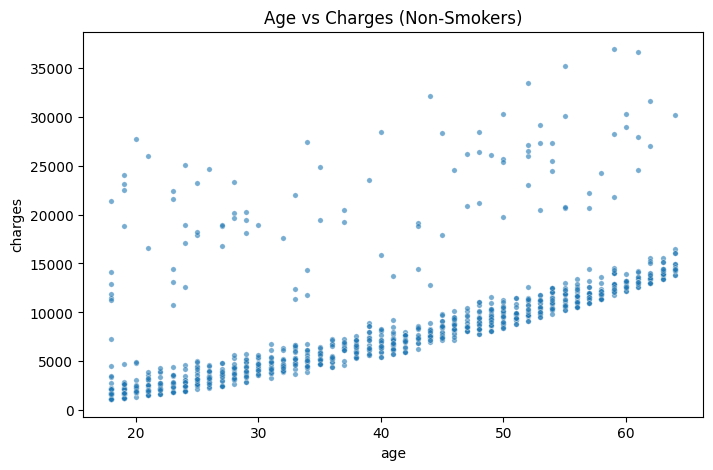

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=non_smokker, x='age', y='charges', alpha=0.6, s=15)
plt.title("Age vs Charges (Non-Smokers)")
plt.show()

In [22]:
def estimate_charges(age,w,b):
    return w* age +b

In [23]:
x = non_smokker['age'].values
y = non_smokker['charges'].values

In [24]:
def error_rmse(x, y, w, b):
    y_pred = estimate_charges(x, w, b)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    return rmse


In [25]:
def try_parameters(x, y, learning_rate=0.0001, epochs=1000):
    
    w = 0
    b = 0
    n = len(x)

    for i in range(epochs):
        
        y_pred = estimate_charges(x, w, b)

      
        dw = (-2/n) * np.sum(x * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

      
        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            rmse = error_rmse(x, y, w, b)
            print(f"Epoch {i}, RMSE: {rmse}")

    return w, b

In [26]:
def try_prediction(age, w, b):
    prediction = estimate_charges(age, w, b)
    print(f"Predicted charge for age {age}: {prediction}")
    return prediction

In [27]:
w, b = try_parameters(x, y)

print("\nFinal Parameters:")
print("Slope (w):", w)
print("Intercept (b):", b)

Epoch 0, RMSE: 7619.436367858424
Epoch 100, RMSE: 4715.34736802545
Epoch 200, RMSE: 4715.109937637556
Epoch 300, RMSE: 4714.8735681918915
Epoch 400, RMSE: 4714.638254999945
Epoch 500, RMSE: 4714.4039933934655
Epoch 600, RMSE: 4714.170778724377
Epoch 700, RMSE: 4713.9386063646925
Epoch 800, RMSE: 4713.70747170644
Epoch 900, RMSE: 4713.477370161568

Final Parameters:
Slope (w): 221.1045843794301
Intercept (b): -41.98126853149978


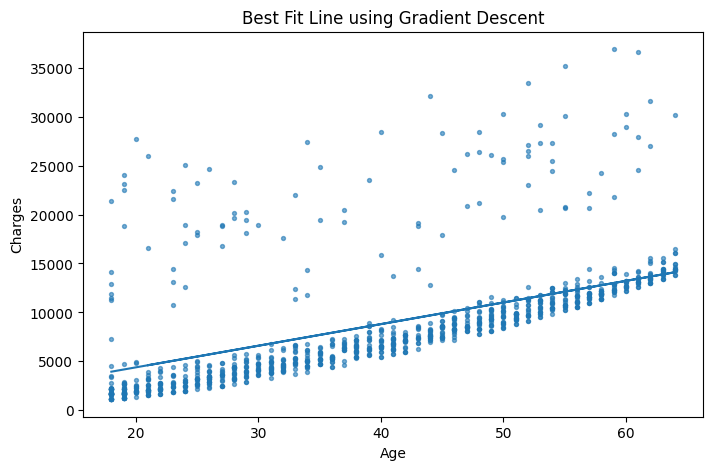

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=8, alpha=0.6)
plt.plot(x, estimate_charges(x, w, b))
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Best Fit Line using Gradient Descent")
plt.show()

In [29]:
try_prediction(30, w, b)

Predicted charge for age 30: 6591.156262851403


6591.156262851403